WEEK 3: DOA INFORMED BEAMFORMING

We voegen ruimtelijke, ongecorreleerde witte ruis toe aan elke microfoon. Het vermogen hiervan moet 10% zijn van het spraakvermogen op de eerste microfoon. Om dit accuraat te berekenen, implementeren we een Voice Activity Detector (VAD) die stiltes negeert en alleen het vermogen berekent tijdens actieve spraaksegmenten. Vervolgens berekenen we de Input Signal-to-Noise Ratio (SNR)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import soundfile as sf
import scipy.signal as signal
import os
import sys
import time
sys.path.append(os.path.abspath('..'))
from package import load_rirs, select_latest_rir
from package.utils import music_wideband

base_path = '..'
path_to_rirs = os.path.join(base_path, 'rirs')
rir_file = select_latest_rir(path_to_rirs)
acoustic_scenario = load_rirs(rir_file)

# Het spraakvermogen wordt uitsluitend berekend over de actieve spraaksegmenten  
# zodat stiltes het gemiddelde niet omlaag trekken. 
def create_micsigs_modified(acoustic_scenario, speech_filenames, noise_filenames, duration):
    fs_rir = acoustic_scenario.fs
    if fs_rir != 44100:
        raise ValueError(f"Fout: Sampling frequency moet 44.1 kHz zijn, maar is {fs_rir} Hz.")
    num_mics = len(acoustic_scenario.RIRs_audio[0])
    num_samples = int(duration * fs_rir)
    
    speech_component = np.zeros((num_samples, num_mics))
    noise_component = np.zeros((num_samples, num_mics))

    for src_idx, filename in enumerate(speech_filenames):
        audio, fs_src = sf.read(filename)
        if fs_src != fs_rir:
            new_len = int(len(audio) * fs_rir / fs_src)
            audio = signal.resample(audio, new_len)
        
        for mic_idx in range(num_mics):
            rir = acoustic_scenario.RIRs_audio[:, mic_idx, src_idx]
            filtered = signal.fftconvolve(audio, rir, mode='full')
            
      
            
            L = min(len(filtered), num_samples)
            speech_component[:L, mic_idx] += filtered[:L]

# RUIS 

    if noise_filenames and len(noise_filenames) > 0 and acoustic_scenario.RIRs_noise is not None:
        for src_idx, filename in enumerate(noise_filenames):
            if not filename: continue
          
            audio, fs_src = sf.read(filename)
            
            if fs_src != fs_rir:
                audio = signal.resample(audio, int(len(audio) * fs_rir / fs_src))
                
            for mic_idx in range(num_mics):
  
                rir = acoustic_scenario.RIRs_noise[:, mic_idx, src_idx]
                filtered = signal.fftconvolve(audio, rir, mode='full')
                
                L = min(len(filtered), num_samples)
                noise_component[:L, mic_idx] += filtered[:L]
    else:
        print("INFO: Ruis-verwerking overgeslagen (geen bestanden of geen ruis-RIRs gevonden).")

    speech_mic1 = speech_component[:, 0]
    vad = np.abs(speech_mic1) > np.std(speech_mic1) * 1e-3
    active_speech = speech_mic1[vad]
    Ps = np.var(active_speech) if len(active_speech) > 0 else 0
    Pn_target = 0.1 * Ps
    white_noise = np.random.normal(0, np.sqrt(Pn_target), (num_samples, num_mics))
       
    noise_component += white_noise
    Pn_actual = np.var(noise_component[:, 0])
    
    
    snr_mic1 = 10 * np.log10(Ps / Pn_actual)
    print(f"SNR in de eerste microfoon: {snr_mic1:.2f} dB")
    

    mic = speech_component + noise_component

    
    return mic, speech_component, noise_component, snr_mic1, vad

In [19]:

speech_files = [
     os.path.join(base_path, "sound_files", "speech1.wav")
]
noise_files = [os.path.join(base_path,"sound_files", "Babble_noise1.wav")]

duration = 5.0
micsigs, speech_comp, noise_comp, SNR_in, vad = create_micsigs_modified(acoustic_scenario, speech_files, noise_files, duration)


SNR in de eerste microfoon: 1.54 dB


DAS BF



1. Eerst gebruiken we het breedband MUSIC-algoritme uit Week 2 om de DOA (Direction of Arrival) van het doelsignaal (dichtbij 90 
∘
 ) te schatten.
2. We berekenen de looptijdsverschillen (τ) tussen de microfoons voor deze hoek.
3. We compenseren deze vertragingen, zodat het doelsignaal constructief interfereert en achtergrondruis destructief interfereert.

In [40]:
def das_bf(scenario, speech_paths, noise_paths=None, duration=10.0):
    if noise_paths is None:
        noise_paths = []

    mic, speech, noise, snr_in, vad = create_micsigs_modified(scenario, speech_paths, noise_paths, duration)

    num_audio = scenario.audioPos.shape[0] if scenario.audioPos is not None else 0
    num_noise = scenario.noisePos.shape[0] if (hasattr(scenario, 'noisePos') and scenario.noisePos is not None) else 0
    Q = num_audio + num_noise
    
    # DOA Schatting
    angles, ps_ind_db, spectrum_geom_db, est_doas = music_wideband(mic, scenario.fs, scenario)

    # Kies de DOA die het dichtst bij 90 graden ligt (broadside direction)
    target_doa = est_doas[np.argmin(np.abs(est_doas - 90.0))]
    print(f"[DAS BF] Target bron gedetecteerd door MUSIC op: {target_doa:.1f}°")
   
    target_rad = np.radians(target_doa)
    c = 343.0
    mics_centered = scenario.micPos - np.mean(scenario.micPos, axis=0)
    taus = (mics_centered[:, 0] * np.sin(target_rad) + mics_centered[:, 1] * np.cos(target_rad)) / c

# Functie om signalen uit te lijnen in het frequentiedomein
#Sub-sample precisie via de Fourier Shift Theorem:
# In plaats van signalen simpelweg een geheel aantal samples (indexen) op te schuiven, 
# passen we de vertraging toe als een faseverschuiving in het frequentiedomein. 
# Hierdoor kunnen we exact "tussen de samples" vertragen, wat afrondingsfouten 
# en faseproblemen voorkomt en resulteert in een veel zuiverdere beamformer.
    def apply_das(signals, delays, fs):
        M = signals.shape[1]
        N = signals.shape[0]
        out_sum = np.zeros(N)
        out_aligned = np.zeros((N, M))
        f = np.fft.rfftfreq(N, 1/fs)
        for m in range(M):
            Sig = np.fft.rfft(signals[:, m]) #reeks van n reele getallen naar complexe getallen-> elk complex getal amplitude en fase van specifieke freq
            Sig_aligned = Sig * np.exp(1j * 2 * np.pi * f * delays[m]) #hoge toon grotere faseverschuiving dan lagere
            t_aligned = np.fft.irfft(Sig_aligned, n=N) #evenveel samples als waarmee je begon
            out_aligned[:, m] = t_aligned
            out_sum += t_aligned #versterken elkaar nu bij optellen
        return out_sum / M, out_aligned

    speechDAS, speech_aligned = apply_das(speech, taus, scenario.fs)
    noiseDAS, noise_aligned = apply_das(noise, taus, scenario.fs)
    
    DASout = speechDAS + noiseDAS
    aligned_mic = speech_aligned + noise_aligned  

    P_speech_das = np.var(speechDAS[vad == 1])
    P_noise_das = np.var(noiseDAS)
    if P_noise_das < 1e-10: P_noise_das = 1e-10
    SNRoutDAS = 10 * np.log10(P_speech_das / P_noise_das)
    print(f"[DAS BF] Output SNR: {SNRoutDAS:.2f} dB")
    
    return DASout, speechDAS, noiseDAS, SNRoutDAS, mic, aligned_mic, vad, snr_in

SNR in de eerste microfoon: 3.73 dB
Q = 2
[DAS BF] Target bron gedetecteerd door MUSIC op: 97.3°
[DAS BF] Output SNR: 6.97 dB


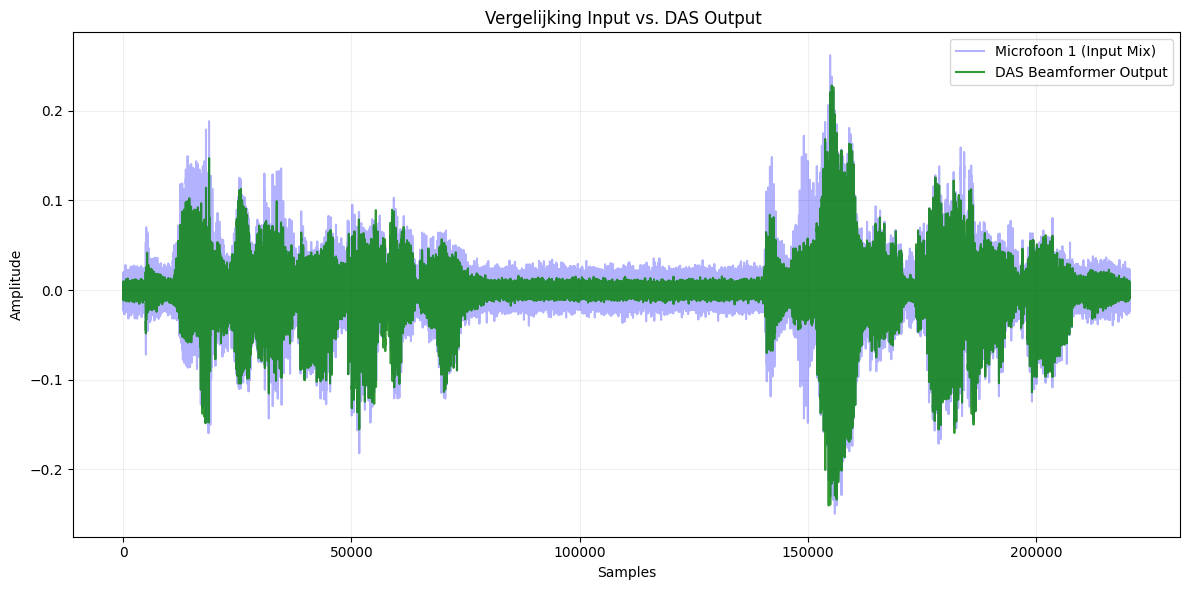

In [ ]:
sys.path.append(os.path.abspath('..'))
base_path = '..'
path_to_rirs = os.path.join(base_path, 'rirs')
rir_file = select_latest_rir(path_to_rirs)
acoustic_scenario = load_rirs(rir_file)



speech_files = [
     os.path.join(base_path, "sound_files", "speech1.wav")
]
noise_files = [os.path.join(base_path,"sound_files", "speech2.wav")] 
duration = 5.0
DASout, speechDAS, noiseDAS, SNRoutDAS,mic, aligned_mics, vad, snr_in= das_bf(acoustic_scenario, speech_files, noise_files, duration)

plt.figure(figsize=(12, 6))

plt.plot(mic[:, 0], color='blue', alpha=0.3, label="Microfoon 1 (Input Mix)")

plt.plot(DASout, color='green', alpha=0.8, label="DAS Beamformer Output")

plt.title(f"Vergelijking Input vs. DAS Output ")
plt.ylabel("Amplitude")
plt.xlabel("Samples")
plt.legend(loc='upper right')
plt.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

Generalized Sidelobe Canceler (GSC)

1. Griffiths-Jim Blocking Matrix (B): Deze matrix (grootte M−1×M) maakt lineaire combinaties van de uitgelijnde signalen (subtractie). Omdat de spraak synchroon loopt, dooft deze uit. Wat overblijft zijn pure 'noise references'.
2. Adaptief Filter (NLMS): Een adaptief FIR-filter leert de relatie tussen de noise references en de rest-ruis in het doelsignaal. We gebruiken μ=0.15, L=1024 en compenseren voor causaliteit met vertraging Δ=L/2.
3. De VAD Fix (Target Cancellation): In een kamer met galm lekt er spraak door de Blocking Matrix. Als het filter continu leert, ziet het deze gelekte spraak als ruis en zal het ons doelsignaal onderdrukken. Door het filter alleen te updaten tijdens stiltes (if vad_delayed[n] == 0), lossen we dit target cancellation probleem op.

In [41]:
def gsc_td(scenario, speech_paths, noise_paths=None, duration=10.0):
    DASout, speechDAS, noiseDAS, SNRoutDAS, mic, aligned_mic, vad, snr_in = das_bf(
        scenario, speech_paths, noise_paths, duration=duration
    )

    N_samples, M_mics = aligned_mic.shape

    # Blocking Matrix B (Griffiths-Jim)
    B = np.zeros((M_mics - 1, M_mics))
    for i in range(M_mics - 1):
        B[i, 0] = 1
        B[i, i + 1] = -1
       
    noise_refs = (B @ aligned_mic.T).T  

    L = 1024
    mu = 0.15
    delta = L // 2

    target_ref = np.pad(DASout, (delta, 0))[:N_samples] #begin das opvullen met nullen
    #bovenste pad vertragen doordat onderste pad vertraging introduceert
    
    W = np.zeros((L, M_mics - 1)) #elke kolom coefficienten voor 1 ruisreferentiekanaal (afkomstig uit blockingmatrix)
    #lengte L bepaalt hoe ver de filter "terugkijkt" om ruispatroon te herkennen
    GSCout = np.zeros(N_samples)
    
    # Adaptatie pauzeert  tijdens spraak (Target Cancellation fix)
    padded_noise = np.pad(noise_refs, ((L-1, 0), (0, 0))) #ruisreferentie aangevuld met L-1 nullen vooraan zodat wanneer je op sample 
    #n=0 begint je een volledige slice van lente L (allemaal nullen) kunt nemen zonder buiten grenzen van lijst te gaan


    eps = 1e-8 # voorkom deling door 0
    vad_delayed = np.pad(vad, (delta, 0))[:N_samples] #zelfde vertraging als spraaksignaal target ref

    for n in range(N_samples):
        X_slice = padded_noise[n : n+L] #pak venster laatste L ruis samples
        
        y_n = np.sum(W * X_slice) #yn gelijk aan ruis in target ref
        e_n = target_ref[n] - y_n #spraak-geschatte ruis
        GSCout[n] = e_n
        
        # Filter updatet alleen als de VAD aangeeft dat er GEEN spraak is
        if vad_delayed[n] == 0:
            power = np.sum(X_slice**2)
            W += (mu * e_n / (power + eps)) * X_slice

    Pn_gsc = np.var(GSCout[vad_delayed == 0])
    Psn_gsc = np.var(GSCout[vad_delayed == 1])
    Ps_gsc = Psn_gsc - Pn_gsc
    if Ps_gsc <= 0: Ps_gsc = 1e-10 
    if Pn_gsc <= 0: Pn_gsc = 1e-10
    
    SNRoutGSC = 10 * np.log10(Ps_gsc / Pn_gsc)
    print(f"[GSC] Output SNR: {SNRoutGSC:.2f} dB (Netto Verbetering vs Mic1: {SNRoutGSC - snr_in:.2f} dB)")

    # Plotting
    t = np.arange(N_samples) / scenario.fs
    GSCout_plot = np.pad(GSCout[delta:], (0, delta)) #verwijder kunstmatige stilte en voeg erna aan einde nullen toe zodat lijst even lang blijft
    
    plt.figure(figsize=(14, 7))
    plt.plot(t, mic[:, 0], color='gray', alpha=0.5, label=f'Microfoon 1 (Input SNR: {snr_in:.1f} dB)')
    plt.plot(t, DASout, color='dodgerblue', alpha=0.6, label=f'DAS Beamformer (SNR: {SNRoutDAS:.1f} dB)')
    plt.plot(t, GSCout_plot, color='green', alpha=0.9, linewidth=1.2, label=f'GSC Output (SNR: {SNRoutGSC:.1f} dB)')
    
    plt.xlabel("Tijd (s)")
    plt.ylabel("Amplitude")
    plt.title("Signaalvergelijking: Origineel vs. DAS-BF vs. GSC")
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.4)
    plt.tight_layout()
    plt.show()

    return GSCout, SNRoutGSC, mic, DASout, GSCout_plot, noise_refs



SNR in de eerste microfoon: 7.25 dB
Q = 3
[DAS BF] Target bron gedetecteerd door MUSIC op: 69.9°
[DAS BF] Output SNR: 10.21 dB
[GSC] Output SNR: 16.66 dB (Netto Verbetering vs Mic1: 9.41 dB)


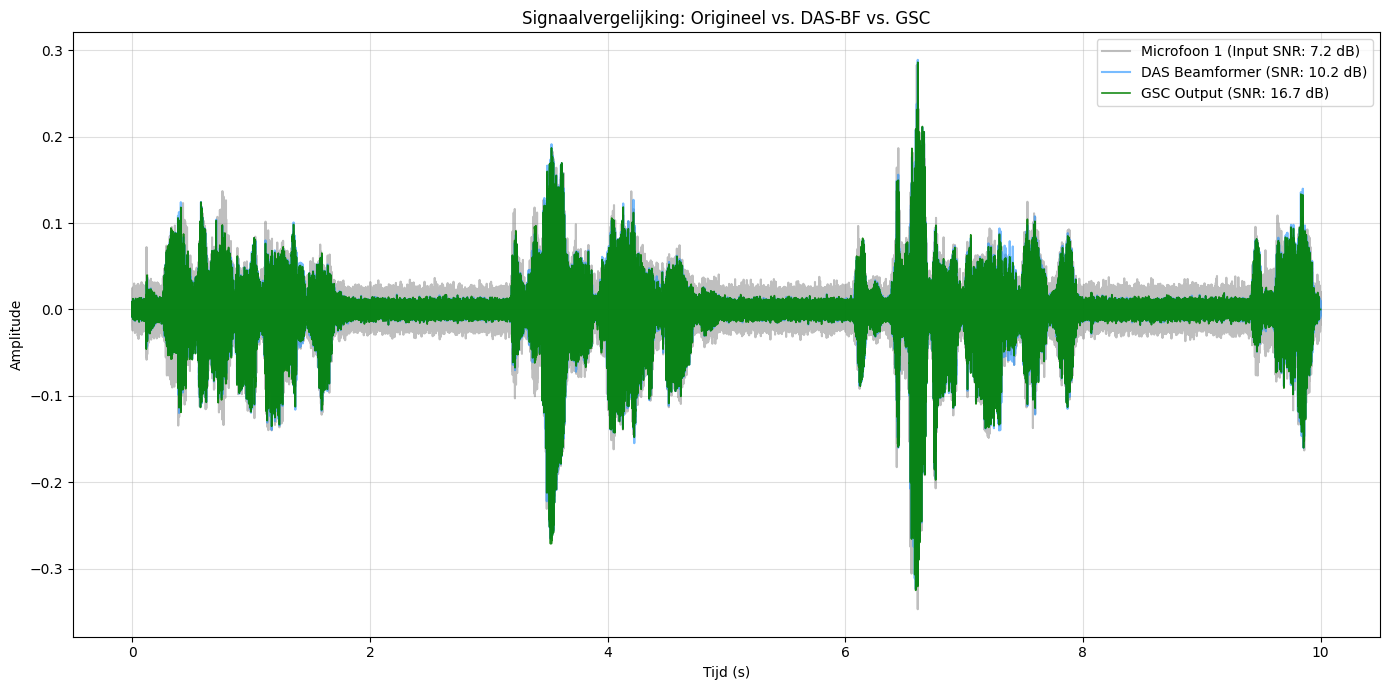

In [42]:
rirs_folder = os.path.join(base_path, 'rirs')
latest_rir = select_latest_rir(path_to_rirs)
scenario = load_rirs(latest_rir)

alle_spraak_bestanden = [
    os.path.join(base_path, "sound_files", "speech1.wav"),
    os.path.join(base_path, "sound_files", "speech2.wav")
]


ruis_pad = os.path.join(base_path, "sound_files", "speech2.wav")
alle_ruis_bestanden = [ruis_pad]

GSCout, SNRoutGSC, mic, DASout, GSCout_plot, noise_refs = gsc_td(scenario, alle_spraak_bestanden, alle_ruis_bestanden, duration=10.0)



Head-Mounted Microphones

In het laatste deel passen we onze GSC met VAD toe op een binaurale, head-mounted setup (bijv. een hoortoestel). Er zijn 4 microfoons (2 per oor, 1.3 cm onderling).
We testen het GSC-algoritme op verschillende subnetwerken: linkeroor, rechteroor, frontaal (y_L1,y_R1) en alle vier samen.

Verwachting: Het algoritme presteert het beste bij de 4-microfoon array, omdat de grotere spatiële spreiding over het hele hoofd resulteert in een betere richtingsgevoeligheid en een effectievere Blocking Matrix voor de ruisonderdrukking.


[Linkeroor (2 mic)] MUSIC 1D Schatting: 125.5°
  -> Input SNR:  13.26 dB
  -> DAS SNR:     13.17 dB (Winst: -0.09 dB)
  -> Output SNR: 14.00 dB (Winst: 0.74 dB)

[Rechteroor (2 mic)] MUSIC 1D Schatting: 114.5°
  -> Input SNR:  7.22 dB
  -> DAS SNR:     7.20 dB (Winst: -0.03 dB)
  -> Output SNR: 8.07 dB (Winst: 0.85 dB)

[Frontaal (2 mic)] MUSIC 1D Schatting: 115.5°
  -> Input SNR:  13.26 dB
  -> DAS SNR:     8.64 dB (Winst: -4.63 dB)
  -> Output SNR: 12.08 dB (Winst: -1.19 dB)

[Alle 4 Mics] MUSIC 2D Schattingen: [ 63.5 116. ]. We kiezen Target DOA: 116.0°
  -> Input SNR:  13.26 dB
  -> DAS SNR:     8.20 dB (Winst: -5.06 dB)
  -> Output SNR: 11.08 dB (Winst: -2.18 dB)


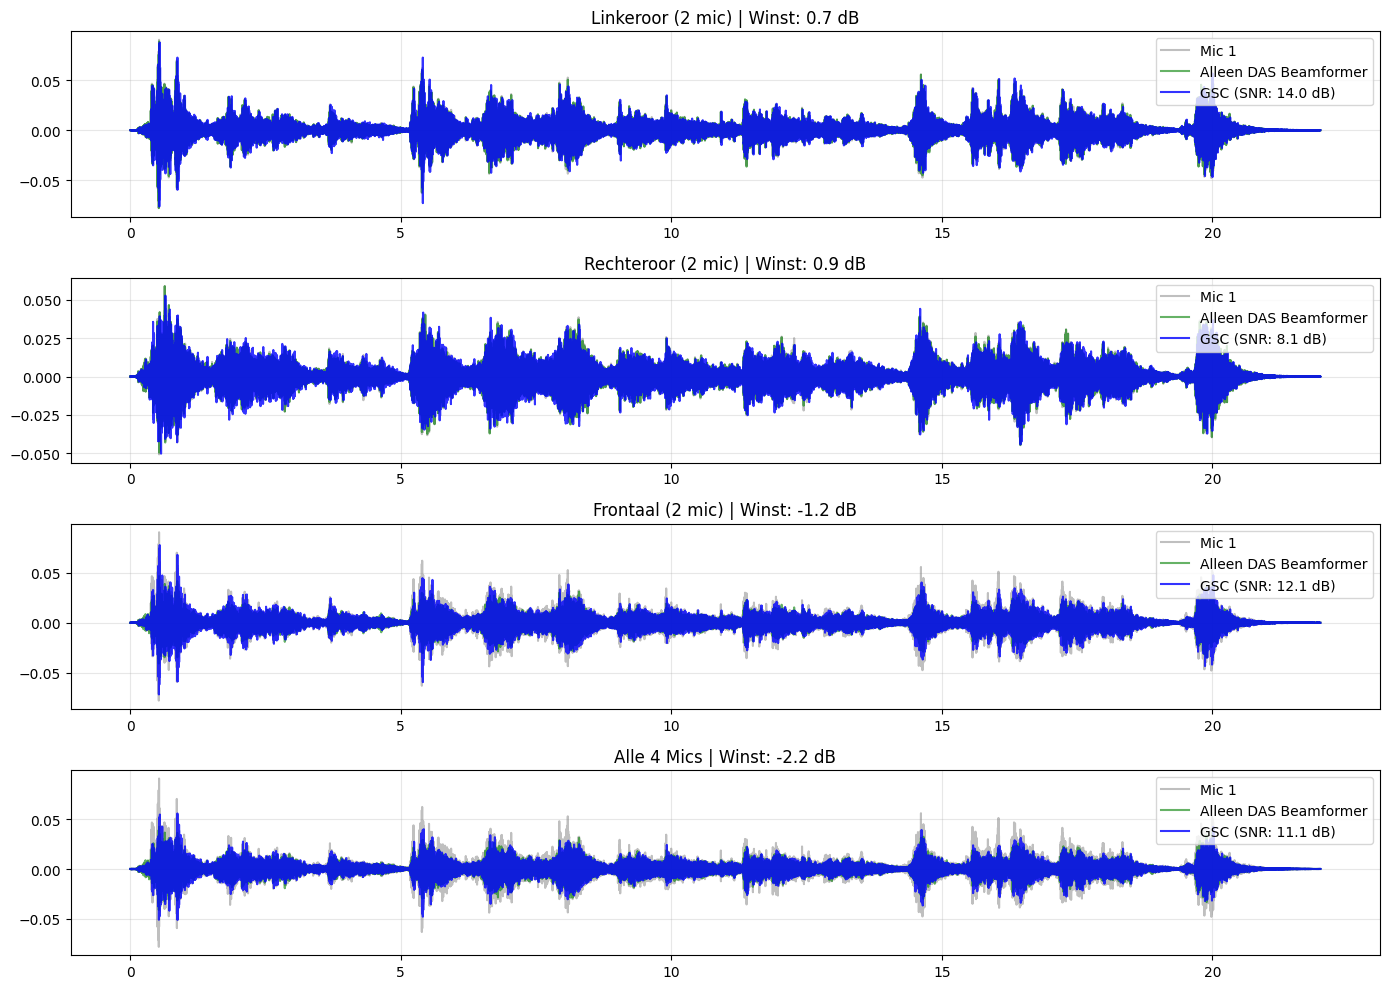

In [8]:
import os
import numpy as np
import soundfile as sf
import scipy.signal as signal
import matplotlib.pyplot as plt

current_dir = os.getcwd()

parent_dir = os.path.abspath(os.path.join(current_dir, ".."))

base_folder = os.path.join(parent_dir, "sound_files", "head_mounted_rirs")
dry_signal_1_path = os.path.join(parent_dir, "sound_files", "part2_track1_dry.wav") 
dry_signal_2_path = os.path.join(parent_dir, "sound_files", "part2_track2_dry.wav")


fs_sim = 44100
c = 343.0
d_ear = 0.013    
d_front = 0.215  

folder_left = "s-30"
folder_right = "s30"


dry_sig_1, _ = sf.read(dry_signal_1_path)
dry_sig_2, _ = sf.read(dry_signal_2_path)
min_len = min(len(dry_sig_1), len(dry_sig_2),20*fs_sim)
dry_sig_1 = dry_sig_1[:min_len]
dry_sig_2 = dry_sig_2[:min_len]

yL1_rir_left, _ = sf.read(os.path.join(base_folder, folder_left, "HMIR_L1.wav"))
yL2_rir_left, _ = sf.read(os.path.join(base_folder, folder_left, "HMIR_L2.wav"))
yR1_rir_left, _ = sf.read(os.path.join(base_folder, folder_left, "HMIR_R1.wav"))
yR2_rir_left, _ = sf.read(os.path.join(base_folder, folder_left, "HMIR_R2.wav"))

yL1_rir_right, _ = sf.read(os.path.join(base_folder, folder_right, "HMIR_L1.wav"))
yL2_rir_right, _ = sf.read(os.path.join(base_folder, folder_right, "HMIR_L2.wav"))
yR1_rir_right, _ = sf.read(os.path.join(base_folder, folder_right, "HMIR_R1.wav"))
yR2_rir_right, _ = sf.read(os.path.join(base_folder, folder_right, "HMIR_R2.wav"))

yL1_from_left = signal.fftconvolve(dry_sig_1, yL1_rir_left, mode='full')
yL2_from_left = signal.fftconvolve(dry_sig_1, yL2_rir_left, mode='full')
yR1_from_left = signal.fftconvolve(dry_sig_1, yR1_rir_left, mode='full')
yR2_from_left = signal.fftconvolve(dry_sig_1, yR2_rir_left, mode='full')

yL1_from_right = signal.fftconvolve(dry_sig_2, yL1_rir_right, mode='full')
yL2_from_right = signal.fftconvolve(dry_sig_2, yL2_rir_right, mode='full')
yR1_from_right = signal.fftconvolve(dry_sig_2, yR1_rir_right, mode='full')
yR2_from_right = signal.fftconvolve(dry_sig_2, yR2_rir_right, mode='full')

yL1_mix = yL1_from_left + yL1_from_right
yL2_mix = yL2_from_left + yL2_from_right
yR1_mix = yR1_from_left + yR1_from_right
yR2_mix = yR2_from_left + yR2_from_right



vad = np.abs(yL1_from_left) > (np.std(yL1_from_left) * 1e-3)


def music_wideband_2mics(micsigs, fs, d, Q=1, orientation="x"):
    L = 1024
    overlap = L // 2
    stft_list = []
    for m in range(micsigs.shape[1]):
        freqs, _, Zxx = signal.stft(micsigs[:, m], fs=fs, window='hann', nperseg=L, noverlap=overlap)
        stft_list.append(Zxx)
    stft_data = np.stack(stft_list, axis=0)
    
    M, nF, nT = stft_data.shape
    angles = np.arange(0, 180.5, 0.5)
    rads = np.radians(angles)
    
    mics_pos = np.array([0, d])
    valid_indices = range(1, L // 2)
    pseudospectra = []
    
    for k in valid_indices:
        Y = stft_data[:, k, :]
        Ryy = (Y @ Y.conj().T) / nT
        _, eigvecs = np.linalg.eigh(Ryy)
        En = eigvecs[:, :M-Q] 
        omega = 2 * np.pi * freqs[k]
        if orientation == "x":
            taus = (mics_pos.reshape(-1, 1) * np.cos(rads)) / c 
        else:
            taus = (mics_pos.reshape(-1, 1) * np.sin(rads)) / c 
        A = np.exp(-1j * omega * taus)
        denom = np.sum(np.abs(En.conj().T @ A)**2, axis=0)
        pseudospectra.append(1.0 / denom)
        
    pseudospectra = np.array(pseudospectra)
    p_geom = np.exp(np.mean(np.log(pseudospectra), axis=0))
    spectrum_db = 10 * np.log10(p_geom / np.max(p_geom))
    peaks_indices, _ = signal.find_peaks(spectrum_db)
    
    sorted_peaks = peaks_indices[np.argsort(spectrum_db[peaks_indices])][-Q:]
    estimated_doas = np.sort(angles[sorted_peaks])
 
    return angles, spectrum_db, estimated_doas

def MUSIC_wideband_HM(micsigs, fs, Q=2):
    L = 1024
    overlap = L // 2
    stft_list = []
    for m in range(micsigs.shape[1]):
        freqs, _, Zxx = signal.stft(micsigs[:, m], fs=fs, window='hann', nperseg=L, noverlap=overlap)
        stft_list.append(Zxx)
    stft_data = np.stack(stft_list, axis=0) 
    M, nF, nT = stft_data.shape
    
    x_ear = 0.215 / 2  
    y_mic = 0.013 / 2  
    mics_pos = np.array([
        [-x_ear,  y_mic],  
        [-x_ear, -y_mic],  
        [ x_ear,  y_mic],  
        [ x_ear, -y_mic]   
    ])
    px = mics_pos[:, 0].reshape(-1, 1)
    py = mics_pos[:, 1].reshape(-1, 1)
    
    angles = np.arange(0, 180.5, 0.5)
    rads = np.radians(angles)
    pseudospectra = []
    for k in range(1, nF - 1):
        Y = stft_data[:, k, :]
        Ryy = (Y @ Y.conj().T) / nT
        _, eigvecs = np.linalg.eigh(Ryy)
        En = eigvecs[:, :M-Q] 
        omega = 2 * np.pi * freqs[k]
        taus = (px * np.cos(rads) + py * np.sin(rads)) / c 
        A = np.exp(1j * omega * taus)
        denom = np.sum(np.abs(En.conj().T @ A)**2, axis=0)
        pseudospectra.append(1.0 / denom)
        
    pseudospectra = np.array(pseudospectra)
    p_geom = np.exp(np.mean(np.log(pseudospectra), axis=0))
    spectrum_db = 10 * np.log10(p_geom / np.max(p_geom))
    peaks_indices, _ = signal.find_peaks(spectrum_db)

    sorted_peaks = peaks_indices[np.argsort(spectrum_db[peaks_indices])][-Q:]
    estimated_doas = np.sort(angles[sorted_peaks])

    return angles, spectrum_db, estimated_doas


def gsc_universal(micsigs, target_doa, fs, vad, is_1d_array=True, d=None, orientation="x"):
    N_samples, M_mics = micsigs.shape
    target_rad = np.radians(target_doa)
    
    # Vertragingen berekenen 
    if is_1d_array:
        
        mics_pos = np.array([0, d])
        if orientation == "x":
            taus = (mics_pos * np.cos(target_rad)) / c
        else:
            taus = (mics_pos * np.sin(target_rad)) / c

    else:
        
        x_ear = 0.215 / 2  
        y_mic = 0.013 / 2  
        mics_pos = np.array([[-x_ear, y_mic], [-x_ear, -y_mic], [x_ear, y_mic], [x_ear, -y_mic]])
        mics_centered = mics_pos - np.mean(mics_pos, axis=0)
        
        taus = (mics_centered[:, 0] * np.cos(target_rad) + mics_centered[:, 1] * np.sin(target_rad)) / c


    # Delay and Sum
    aligned_mic = np.zeros_like(micsigs)
    DASout = np.zeros(N_samples)
    f = np.fft.rfftfreq(N_samples, 1/fs)
    for m in range(M_mics):
        Sig = np.fft.rfft(micsigs[:, m])
        Sig_aligned = Sig * np.exp(1j * 2 * np.pi * f * taus[m])
        t_aligned = np.fft.irfft(Sig_aligned, n=N_samples)
        aligned_mic[:, m] = t_aligned
        DASout += t_aligned
    DASout /= M_mics

    Pn_das = np.var(DASout[vad == 0])
    Psn_das = np.var(DASout[vad == 1])
    Ps_das = Psn_das - Pn_das
    SNR_das = 10 * np.log10(max(Ps_das, 1e-10) / max(Pn_das, 1e-10))
    # Blocking Matrix
    B = np.zeros((M_mics - 1, M_mics))
    for i in range(M_mics - 1):
        B[i, i] = 1
        B[i, i + 1] = -1
    noise_refs = (B @ aligned_mic.T).T
    

    # plt.figure(figsize=(12, 6))

    # # Pak de eerste ruisreferentie (bijv. L1 - L2)
    # noise_ref_1 = noise_refs[:, 0]

    # # Plot het originele signaal en de ruisreferentie over elkaar
    # t = np.arange(len(noise_ref_1)) / fs_sim
    # plt.plot(t, micsigs[:, 0], color='gray', alpha=0.4, label='Origineel (Mic 1)')
    # plt.plot(t, noise_ref_1, color='red', alpha=0.7, label='Ruisreferentie (BM Output)')

    # plt.title("Blocking Matrix Check: Wordt de spraak onderdrukt?")
    # plt.xlabel("Tijd (s)")
    # plt.ylabel("Amplitude")
    # plt.legend()
    # plt.grid(True, alpha=0.3)
    # plt.show()

    # # Bereken de onderdrukkingsfactor in dB tijdens spraak (VAD == 1)
    # leakage_power = np.var(noise_ref_1[vad == 1])
    # original_power = np.var(micsigs[vad == 1, 0])
    # suppression = 10 * np.log10(original_power / leakage_power)

    # print(f"Spraakonderdrukking in de BM: {suppression:.2f} dB")
    # if suppression < 10:
    #     print("WAARSCHUWING: Weinig onderdrukking. De spraak lekt door naar het filter!")
    # else:
    #     print("Goede onderdrukking. Het filter kan veilig updaten.")

    # NLMS met VAD
    L = 1024 
    mu = 0.1
    delta = L // 2
    
    target_ref = np.pad(DASout, (delta, 0))[:N_samples]
    vad_delayed = np.pad(vad, (delta, 0))[:N_samples]
    padded_noise = np.pad(noise_refs, ((L-1, 0), (0, 0)))
    
    W = np.zeros((L, M_mics - 1))
    GSCout = np.zeros(N_samples)
    eps = 1e-8
    
    for n in range(N_samples):
        X_slice = padded_noise[n : n+L]
        y_n = np.sum(W * X_slice)
        e_n = target_ref[n] - y_n
        GSCout[n] = e_n
        
        if vad_delayed[n] == 0:
            power = np.sum(X_slice**2)
            W += (mu * e_n / (power + eps)) * X_slice
            
    # SNR
    Pn = np.var(GSCout[vad_delayed == 0])
    Psn = np.var(GSCout[vad_delayed == 1])
    Ps = Psn - Pn
    if Ps < 1e-10: Ps = 1e-10
    if Pn < 1e-10: Pn = 1e-10
    SNRout = 10 * np.log10(Ps / Pn)
    
    Pn_in = np.var(micsigs[vad == 0, 0])
    Psn_in = np.var(micsigs[vad == 1, 0])
    Ps_in = Psn_in - Pn_in
    if Ps_in < 1e-10: Ps_in = 1e-10
    if Pn_in < 1e-10: Pn_in = 1e-10
    SNRin = 10 * np.log10(Ps_in / Pn_in)
    
    return GSCout, SNRout, SNRin, DASout, SNR_das




# Data combinaties
arrays = {
    "Linkeroor (2 mic)":   {"mics": np.column_stack((yL1_mix, yL2_mix)), "1d": True, "d": d_ear,"orientation": "y"},
    "Rechteroor (2 mic)":  {"mics": np.column_stack((yR1_mix, yR2_mix)), "1d": True, "d": d_ear,"orientation": "y"},
    "Frontaal (2 mic)":    {"mics": np.column_stack((yL1_mix, yR1_mix)), "1d": True, "d": d_front, "orientation": "x"},
    "Alle 4 Mics":         {"mics": np.column_stack((yL1_mix, yL2_mix, yR1_mix, yR2_mix)), "1d": False, "d": 0, "orientation": "2d"}
}

results = {}

for name, config in arrays.items():
    micsigs = config["mics"]
    orientation= config["orientation"]
   
    if config["1d"]:
        _, _, est_doas = music_wideband_2mics(micsigs, fs_sim, config["d"], Q=1,orientation=orientation)
         
        target_doa = est_doas[0]
        print(f"\n[{name}] MUSIC 1D Schatting: {target_doa:.1f}°")
    else:
        _, _, est_doas = MUSIC_wideband_HM(micsigs, fs_sim, Q=2)
        #doa dichtste bij bron
        target_doa = est_doas[np.argmax(est_doas)] 
        print(f"\n[{name}] MUSIC 2D Schattingen: {est_doas}. We kiezen Target DOA: {target_doa:.1f}°")

    
    GSCout, SNRout, SNRin, DAS_signal,SNRdas = gsc_universal(
        micsigs=micsigs,
        target_doa=target_doa,
        fs=fs_sim,
        vad=vad,
        is_1d_array=config["1d"],
        d=config["d"],
        orientation=orientation
    )
    
    results[name] = {"out": GSCout, "snr_in": SNRin, "snr_out": SNRout, "das": DAS_signal, "snr_das": SNRdas}
    print(f"  -> Input SNR:  {SNRin:.2f} dB")
    print(f"  -> DAS SNR:     {SNRdas:.2f} dB (Winst: {SNRdas - SNRin:.2f} dB)")
    print(f"  -> Output SNR: {SNRout:.2f} dB (Winst: {SNRout - SNRin:.2f} dB)")

# Plot 
t = np.arange(len(yL1_mix)) / fs_sim
plt.figure(figsize=(14, 10))
for i, (name, res) in enumerate(results.items()):
    plt.subplot(4, 1, i+1)
    #origineel
    plt.plot(t, arrays[name]["mics"][:, 0], color='gray', alpha=0.5, label='Mic 1')
    #  DAS 
    plt.plot(t, res["das"], color='green', alpha=0.6, label='Alleen DAS Beamformer')
    #gsc
    plt.plot(t, res["out"], color='blue', alpha=0.8, label=f'GSC (SNR: {res["snr_out"]:.1f} dB)')
    plt.title(f"{name} | Winst: {res['snr_out'] - res['snr_in']:.1f} dB")
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Om de theorie en de grafieken in de praktijk te verifiëren, exporteren we hier de verwerkte signalen naar .wav bestanden. We slaan de resultaten op van zowel de lineaire array als de binaurale head-mounted array. 

Alle signalen worden eerst genormaliseerd om clipping te voorkomen

In [ ]:
import soundfile as sf
import os



if 'mic' in locals() and 'DASout' in locals() and 'GSCout_plot' in locals():
    
    # 1. Origineel Signaal (Mic 1)
    mic_audio = mic[:, 0] / np.max(np.abs(mic[:, 0]))
    sf.write("Week3_Demo_01_Origineel_Mic1.wav", mic_audio, scenario.fs)

    # 2. DAS Beamformer Signaal
    das_audio = DASout / np.max(np.abs(DASout))
    sf.write("Week3_Demo_02_Verbeterd_DAS.wav", das_audio, scenario.fs)

    # 3. Volledige GSC Output
    gsc_audio = GSCout_plot / np.max(np.abs(GSCout_plot))
    sf.write("Week3_Demo_03_GSC_Filter.wav", gsc_audio, scenario.fs)


# 2. Audio van de Head-Mounted Array

if 'results' in locals() and 'fs_sim' in locals():
    
    # Referentie: Onbewerkt signaal op het Linkeroor
    ref_mic = yL1_mix / np.max(np.abs(yL1_mix))
    sf.write("Week3_Demo_04_HM_Referentie_MicL1.wav", ref_mic, fs_sim)
    
    # Sla de GSC resultaten op per head-mounted array-configuratie
    for name, data in results.items():
        audio_data = data["out"]
        
        # Normaliseren naar -1 en 1
        max_val = np.max(np.abs(audio_data))
        audio_norm = audio_data / max_val if max_val > 0 else audio_data

        # Bestandsnaam opschonen (geen spaties, komma's of haakjes)
        clean_name = name.replace(" ", "_").replace("(", "").replace(")", "").replace(",", "")
        filename = f"Week3_Demo_05_HM_GSC_{clean_name}.wav"
        
        sf.write(filename, audio_norm, fs_sim)




--- AUDIO BESTANDEN OPSLAAN VOOR DEMO ---

Opgeslagen: Week3_Demo_04_HM_Referentie_MicL1.wav
Opgeslagen: Week3_Demo_05_HM_GSC_Linkeroor_2_mic.wav
Opgeslagen: Week3_Demo_05_HM_GSC_Rechteroor_2_mic.wav
Opgeslagen: Week3_Demo_05_HM_GSC_Frontaal_2_mic.wav
Opgeslagen: Week3_Demo_05_HM_GSC_Alle_4_Mics.wav

Klaar! De audiobestanden staan nu in dezelfde map als deze notebook.
